In [1]:
import seaborn as sns
import matplotlib
matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import pandas as pd
import os
import matplotlib.cm as cm

In [11]:

# create folder to store results if not exist
#result_path= "C:/Users/Mahima Acharya/Documents/BCI/Data/EEG_Result/Classification"
result_path= "C:/Users/Mahima Acharya/Documents/BCI/Data/EEG_Result/Classification/AR"
if not os.path.exists(result_path):
    os.makedirs(result_path)

# create folder to store results if not exist
#result_plot= "C:/Users/Mahima Acharya/Documents/BCI/Data/EEG_Result/Classification/plots"
result_plot= "C:/Users/Mahima Acharya/Documents/BCI/Data/EEG_Result/Classification/plots/AR"
if not os.path.exists(result_plot):
    os.makedirs(result_plot)

## load the Data

In [12]:
#df_result = pd.read_csv(result_path+'/bin_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_result = pd.read_csv(result_path+'/mcl_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_result

,Focus,Data,FrequencyBand,X_shape,y_shape,Classifier,CV,Accuracy,Expert Precision,Expert Recall,...,Intermediate Precision,Intermediate Recall,Intermediate F1-Score,Intermediate Support,Novice Precision,Novice Recall,Novice F1-Score,Novice Support,Best Group,Best Accuracy
0,Algorithm,Baseline,4to50hz,"(1072, 1)","(1072,)",RF,Stratified10-fold CV,69.3120,70.66,73.78,...,66.10,62.62,64.05,3450.00,71.55,70.84,70.99,3190.00,NaN,NaN
1,Algorithm,Baseline,4to50hz,"(1072, 1)","(1072,)",RF,Leave-One-Subject-Out CV,56.3933,42.86,28.46,...,34.38,17.51,21.16,1078.12,30.56,20.26,23.06,886.11,[49],100.0000
2,Algorithm,Baseline,4to50hz,"(1072, 1)","(1072,)",RF,Leave-One-Algorithm-Out CV,68.5948,70.56,71.63,...,66.01,62.48,63.35,1078.12,72.29,71.21,71.10,996.88,['BogoSort'],85.7143
3,Algorithm,Baseline,4to50hz,"(1072, 1)","(1072,)",SVM,Stratified10-fold CV,65.0182,56.59,93.62,...,80.59,33.64,47.21,3450.00,79.97,62.43,69.83,3190.00,NaN,NaN
4,Algorithm,Baseline,4to50hz,"(1072, 1)","(1072,)",SVM,Leave-One-Subject-Out CV,54.0585,44.44,43.63,...,27.78,4.11,6.67,1916.67,47.06,44.01,45.39,1876.47,[71],100.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2368, 4)","(2368,)",SVM,Leave-One-Subject-Out CV,64.2736,54.55,52.49,...,33.33,19.92,22.91,3200.00,45.00,37.27,38.78,3840.00,[71],100.0000
68,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2368, 4)","(2368,)",SVM,Leave-One-Electrode-Out CV,68.6656,64.08,90.02,...,73.50,47.79,57.54,1200.00,73.68,66.41,69.68,1200.00,['FC4'],72.9730
69,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2368, 4)","(2368,)",XGB,Stratified10-fold CV,77.9561,73.07,83.17,...,77.89,68.75,72.94,7680.00,84.56,81.50,82.94,7680.00,NaN,NaN
70,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2368, 4)","(2368,)",XGB,Leave-One-Subject-Out CV,54.2652,52.17,38.38,...,35.48,13.61,16.29,2477.42,34.38,21.97,24.68,2400.00,[24],100.0000


## Multi Plot

In [14]:

sns.set(style="whitegrid")
# Number of plots to create for AR
num_plots = 8
rows_per_plot = 9
plots_per_row = 4
"""

# Number of plots to create for BCA
num_plots = 4
rows_per_plot = 9
plots_per_row = 2"""


cv_names = ['Stratified10-fold CV', 'Leave-One-Subject-Out CV', 'Leave-One-Algorithm-Out CV', 'Leave-One-Electrode-Out CV']
cv_colors = {cv_name: cm.inferno(i/(len(cv_names))) for i, cv_name in enumerate(cv_names)}





metrics= ['Accuracy', 'Expert Precision','Expert Recall', 'Expert F1-Score',
          'Intermediate Precision','Intermediate Recall', 'Intermediate F1-Score',
    'Novice Precision','Novice Recall', 'Novice F1-Score']

#Loop through metrics
for metric in metrics:
    # Create a grid of subplots with two rows
    fig, axes = plt.subplots(nrows=2, ncols=plots_per_row, figsize=(10,6 ))
    # Loop through the plots
    for i in range(num_plots):
        # Select 9 rows for the current plot
        start_idx = i * rows_per_plot
        end_idx = (i + 1) * rows_per_plot
        subset_df = df_result.iloc[start_idx:end_idx, :]
        focus = df_result.iloc[start_idx]['Focus']
        data = df_result.iloc[start_idx]['Data']
        freq_band = df_result.iloc[start_idx]['FrequencyBand']
        # Determine the subplot position
        row_idx = i // plots_per_row
        col_idx = i % plots_per_row

        # Create a bar plot for accuracy vs classifier
        ax = sns.barplot(x="Classifier", y=metric, hue="CV", data=subset_df, ax=axes[row_idx, col_idx], 
                        ci=None,palette=cv_colors)

        focus_name = "Alg" if focus == "Algorithm" else "EP"
        
        # Customize plot aesthetics
        ax.set_title(f"{i + 1}: {focus_name}_{data}_{freq_band}")
        ax.set_xlabel("Classifier")
        ax.set_ylabel(metric)
        ax.legend().set_visible(False)
        

        """# Set y-axis ticks with a distance of 0.1
        ax.set_yticks([tick / 10 for tick in range(11)])"""
        ax.set_yticks([tick * 10 for tick in range(11)])

        # Show the legend only for plots 4 and 8
        ax.legend().set_visible(False)

    
    # Create a custom legend based on the color palette
    legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in cv_colors.values()]
    legend_names = list(cv_colors.keys())

    #label bar for 8 plots for AR
    plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
            bbox_to_anchor=(-1.5, -0.1), loc='upper center', ncol=4).set_visible(True)
    
    """#label bar for 4 plots for BCA
    plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
            bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1).set_visible(True)"""

    #plt.suptitle(f'{metric} Visualisation of Binary Classification (Expert vs. Novice)',fontsize=16, fontweight='bold')
    plt.suptitle(f'{metric} Visualisation of Multiclass Classification (Expert vs. Intermediate vs. Novice)',fontsize=16, fontweight='bold')
    # Adjust the layout to prevent clipping of titles
    plt.subplots_adjust(top=0.9)

    # Adjust layout and show the plots
    plt.tight_layout(pad= 2)
    #plt.savefig(result_plot + f'/bin_clf_result_{metric}.png')
    plt.savefig(result_plot + f'/mcl_clf_result_{metric}.png')
    plt.show()


C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\3513035073.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="Classifier", y=metric, hue="CV", data=subset_df, ax=axes[row_idx, col_idx],
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\3513035073.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="Classifier", y=metric, hue="CV", data=subset_df, ax=axes[row_idx, col_idx],
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\3513035073.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="Classifier", y=metric, hue="CV", data=subset_df, ax=axes[row_idx, col_idx],
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\3513035073.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="Clas

: 

In [ ]:
def get_bar_plots(method, num_class ):

    sns.set(style="whitegrid")
    if method == 'CAR':
        # Number of plots to create for CAR
        num_plots = 8
        rows_per_plot = 9
        plots_per_row = 4
    elif method == 'BCA': 
        # Number of plots to create for BCA
        num_plots = 4
        rows_per_plot = 9
        plots_per_row = 2


    cv_names = ['Stratified10-fold CV', 'Leave-One-Subject-Out CV', 'Leave-One-Algorithm-Out CV', 'Leave-One-Electrode-Out CV']
    cv_colors = {cv_name: cm.inferno(i/(len(cv_names))) for i, cv_name in enumerate(cv_names)}

    if num_class == 2: 
    metrics= ['Accuracy', 'Expert Precision','Expert Recall', 'Expert F1-Score',
        'Novice Precision','Novice Recall', 'Novice F1-Score']

    #Loop through metrics
    for metric in metrics:
        # Create a grid of subplots with two rows
        fig, axes = plt.subplots(nrows=2, ncols=plots_per_row, figsize=(10,6 ))
        # Loop through the plots
        for i in range(num_plots):
            # Select 9 rows for the current plot
            start_idx = i * rows_per_plot
            end_idx = (i + 1) * rows_per_plot
            subset_df = df_result.iloc[start_idx:end_idx, :]
            focus = df_result.iloc[start_idx]['Focus']
            data = df_result.iloc[start_idx]['Data']
            freq_band = df_result.iloc[start_idx]['FrequencyBand']
            # Determine the subplot position
            row_idx = i // plots_per_row
            col_idx = i % plots_per_row

            # Create a bar plot for accuracy vs classifier
            ax = sns.barplot(x="Classifier", y=metric, hue="CV", data=subset_df, ax=axes[row_idx, col_idx], 
                            ci=None,palette=cv_colors)

            focus_name = "Alg" if focus == "Algorithm" else "EP"
            
            # Customize plot aesthetics
            ax.set_title(f"{i + 1}: {focus_name}_{data}_{freq_band}")
            ax.set_xlabel("Classifier")
            ax.set_ylabel(metric)
            ax.legend().set_visible(False)
            

            """# Set y-axis ticks with a distance of 0.1
            ax.set_yticks([tick / 10 for tick in range(11)])"""
            ax.set_yticks([tick * 10 for tick in range(11)])

            # Show the legend only for plots 4 and 8
            ax.legend().set_visible(False)

        
        # Create a custom legend based on the color palette
        legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in cv_colors.values()]
        legend_names = list(cv_colors.keys())

        """#label bar for 8 plots for AR
        plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
                bbox_to_anchor=(-1.5, -0.1), loc='upper center', ncol=4).set_visible(True)"""
        
        #label bar for 4 plots for BCA
        plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
                bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1).set_visible(True)

        plt.suptitle(f'{metric} Visualisation of Binary Classification (Expert vs. Novice)',fontsize=16, fontweight='bold')
        #plt.suptitle(f'{metric} Visualisation of Multiclass Classification (Expert vs. Intermediate vs. Novice)',fontsize=16, fontweight='bold')
        # Adjust the layout to prevent clipping of titles
        plt.subplots_adjust(top=0.9)

        # Adjust layout and show the plots
        plt.tight_layout(pad= 2)
        plt.savefig(result_plot + f'/bin_clf_result_{metric}.png')
        #plt.savefig(result_plot + f'/mcl_clf_result_{metric}.png')
        plt.show()


## One Plot

In [7]:

sns.set(style="whitegrid")

cv_names = ['Stratified10-fold CV', 'Leave-One-Subject-Out CV', 'Leave-One-Algorithm-Out CV', 'Leave-One-Electrode-Out CV']
cv_colors = {cv_name: cm.inferno(i/(len(cv_names))) for i, cv_name in enumerate(cv_names)}

metrics= ['Accuracy', 'Expert Precision','Expert Recall', 'Expert F1-Score',
          'Intermediate Precision','Intermediate Recall', 'Intermediate F1-Score',
    'Novice Precision','Novice Recall', 'Novice F1-Score']

#Loop through metrics
for metric in metrics:
    plt.figure(figsize=(10,6))
    # Loop through the plots
    focus = df_result['Focus']
    data = df_result['Data']
    freq_band = df_result['FrequencyBand']
    sns.barplot(x="Classifier", y=metric, hue="CV", data=df_result,  ci=None,palette=cv_colors)
         
    # Customize plot aesthetics
    #plt.title(f"{focus}_{data}_{freq_band}")
    plt.xlabel("Classifier")
    plt.ylabel(metric)
    plt.yticks([tick * 10 for tick in range(11)])

    # Create a custom legend based on the color palette
    legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in cv_colors.values()]
    legend_names = list(cv_colors.keys())

    #label bar for 4 plots for BCA
    plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
            bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1).set_visible(True)

    #plt.title(f'{metric} Visualisation of Binary Classification (Expert vs. Novice)',fontsize=16, fontweight='bold')
    plt.title(f'{metric} Visualisation of Multiclass Classification (Expert vs. Intermediate vs. Novice)',fontsize=16, fontweight='bold')
    # Adjust the layout to prevent clipping of titles
    plt.subplots_adjust(top=0.9)

    # Adjust layout and show the plots
    plt.tight_layout(pad= 2)
    #plt.savefig(result_plot + f'/bin_clf_result_{metric}.png')
    plt.savefig(result_plot + f'/mcl_clf_result_{metric}.png')
    plt.show()


C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\785943551.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Classifier", y=metric, hue="CV", data=df_result,  ci=None,palette=cv_colors)
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\785943551.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Classifier", y=metric, hue="CV", data=df_result,  ci=None,palette=cv_colors)
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\785943551.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Classifier", y=metric, hue="CV", data=df_result,  ci=None,palette=cv_colors)
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_38884\785943551.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Classifier", y=metric, hu

# Compare between different classifiers' accuracies

In [31]:
result_path_clf = "C:/Users/Mahima Acharya/Documents/BCI/Data/EEG_Result/Classification"
result_path_bca= result_path_clf + "/BCA"
result_path_ar = result_path_clf + "/AR"
result_path_bca_ec = result_path_clf + "/BCA_EC"
result_path_ar_ec = result_path_clf + "/AR_EC"

In [33]:
# Load Correlation DataFrames from BCA folders
df_bin_clf_bca = pd.read_csv(result_path_bca+'/bin_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_mcl_clf_bca = pd.read_csv(result_path_bca+'/mcl_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_bin_clf_ar = pd.read_csv(result_path_ar+'/bin_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_mcl_clf_ar = pd.read_csv(result_path_ar+'/mcl_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_bin_clf_bca_ec = pd.read_csv(result_path_bca_ec+'/bin_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_mcl_clf_bca_ec = pd.read_csv(result_path_bca_ec+'/mcl_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_bin_clf_ar_ec = pd.read_csv(result_path_ar_ec+'/bin_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")
df_mcl_clf_ar_ec = pd.read_csv(result_path_ar_ec+'/mcl_clf_result.csv').drop("Unnamed: 0", axis=1, errors="ignore")


"""df_bin_clf_bca['DataframeName'] = 'bin_clf_bca'
df_mcl_clf_bca['DataframeName'] = 'mcl_clf_bca'
df_bin_clf_ar['DataframeName'] = 'bin_clf_ar'
df_mcl_clf_ar['DataframeName'] = 'mcl_clf_ar'
df_bin_clf_bca_ec['DataframeName'] = 'bin_clf_bca_ec'
df_mcl_clf_bca_ec['DataframeName'] = 'mcl_clf_bca_ec'
df_bin_clf_ar_ec['DataframeName'] = 'bin_clf_ar_ec'
df_mcl_clf_ar_ec['DataframeName'] = 'mcl_clf_ar_ec'"""



df_bin_clf_bca['Number of Classes'] = 2
df_mcl_clf_bca['Number of Classes'] = 3
df_bin_clf_ar['Number of Classes'] = 2
df_mcl_clf_ar['Number of Classes'] = 3
df_bin_clf_bca_ec['Number of Classes'] = 2
df_mcl_clf_bca_ec['Number of Classes'] = 3
df_bin_clf_ar_ec['Number of Classes'] = 2
df_mcl_clf_ar_ec['Number of Classes'] = 3


df_bin_clf_bca['Pre-Processed Algorithm'] = 'Baseline Correction Method' 
df_mcl_clf_bca['Pre-Processed Algorithm'] = 'Baseline Correction Method'
df_bin_clf_ar['Pre-Processed Algorithm'] = 'Average Common Referencing' 
df_mcl_clf_ar['Pre-Processed Algorithm'] = 'Average Common Referencing' 
df_bin_clf_bca_ec['Pre-Processed Algorithm'] = 'Baseline Correction Method'
df_mcl_clf_bca_ec['Pre-Processed Algorithm'] = 'Baseline Correction Method'
df_bin_clf_ar_ec['Pre-Processed Algorithm'] = 'Average Common Referencing' 
df_mcl_clf_ar_ec['Pre-Processed Algorithm'] = 'Average Common Referencing' 

df_bin_clf_bca['Channel Reduction'] = 'No' 
df_mcl_clf_bca['Channel Reduction'] = 'No'
df_bin_clf_ar['Channel Reduction'] = 'No'
df_mcl_clf_ar['Channel Reduction'] = 'No' 
df_bin_clf_bca_ec['Channel Reduction'] = 'Yes'
df_mcl_clf_bca_ec['Channel Reduction'] = 'Yes'
df_bin_clf_ar_ec['Channel Reduction'] = 'Yes'
df_mcl_clf_ar_ec['Channel Reduction'] = 'Yes' 


df_concatenate = pd.concat([df_bin_clf_bca, df_mcl_clf_bca, df_bin_clf_ar, df_mcl_clf_ar, 
                           df_bin_clf_bca_ec, df_mcl_clf_bca_ec, df_bin_clf_ar_ec, df_mcl_clf_ar_ec ], ignore_index=True)
#df_concatenate.to_csv(result_path_clf+'/all_result.csv')
df_concatenate

,Focus,Data,FrequencyBand,X_shape,y_shape,Classifier,CV,Accuracy,Expert Precision,Expert Recall,...,Novice Support,Best Group,Best Accuracy,Number of Classes,Pre-Processed Algorithm,Channel Reduction,Intermediate Precision,Intermediate Recall,Intermediate F1-Score,Intermediate Support
0,Algorithm,CodeComprehension,4to50hz,"(727, 1)","(727,)",RF,Stratified10-fold CV,84.8744,87.03,86.02,...,3190.00,NaN,NaN,2,Baseline Correction Method,No,NaN,NaN,NaN,NaN
1,Algorithm,CodeComprehension,4to50hz,"(727, 1)","(727,)",RF,Leave-One-Subject-Out CV,76.4667,60.00,53.12,...,1276.00,[55],100.0000,2,Baseline Correction Method,No,NaN,NaN,NaN,NaN
2,Algorithm,CodeComprehension,4to50hz,"(727, 1)","(727,)",RF,Leave-One-Algorithm-Out CV,85.2868,87.08,87.28,...,996.88,['SiebDesEratosthenes'],95.2381,2,Baseline Correction Method,No,NaN,NaN,NaN,NaN
3,Algorithm,CodeComprehension,4to50hz,"(727, 1)","(727,)",SVM,Stratified10-fold CV,83.7595,80.76,93.62,...,3190.00,NaN,NaN,2,Baseline Correction Method,No,NaN,NaN,NaN,NaN
4,Algorithm,CodeComprehension,4to50hz,"(727, 1)","(727,)",SVM,Leave-One-Subject-Out CV,83.7500,75.00,74.61,...,2126.67,[71],100.0000,2,Baseline Correction Method,No,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2220, 4)","(2220,)",SVM,Leave-One-Subject-Out CV,64.9550,54.55,52.73,...,3428.57,[71],100.0000,3,Average Common Referencing,Yes,31.82,21.82,24.99,3272.73
248,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2220, 4)","(2220,)",SVM,Leave-One-Electrode-Out CV,68.6487,63.99,90.00,...,1200.00,['Fz'],75.6757,3,Average Common Referencing,Yes,73.78,47.22,57.23,1200.00
249,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2220, 4)","(2220,)",XGB,Stratified10-fold CV,77.8378,72.63,81.67,...,7200.00,NaN,NaN,3,Average Common Referencing,Yes,77.13,69.17,72.88,7200.00
250,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(2220, 4)","(2220,)",XGB,Leave-One-Subject-Out CV,56.7117,54.55,41.14,...,2250.00,[24],100.0000,3,Average Common Referencing,Yes,34.38,13.75,16.39,2250.00


In [34]:

# Sort the data frame by the 'accuracy' column in descending order
df_sorted = df_concatenate.sort_values(by='Accuracy', ascending=False)
df_sorted = df_sorted[['Number of Classes', 'Pre-Processed Algorithm', 'Channel Reduction',
                        'Focus',	'Data',	'FrequencyBand', 'X_shape',	'y_shape',	'Classifier',	'CV',	'Accuracy',
                       'Expert Precision','Expert Recall', 'Expert F1-Score', 'Expert Support',
                                             'Intermediate Precision','Intermediate Recall', 'Intermediate F1-Score', 'Intermediate Support', 
                                             'Novice Precision','Novice Recall', 'Novice F1-Score', 'Novice Support',  
                                      'Best Group', 'Best Accuracy']]
df_sorted.to_csv(result_path_clf+'/all_result.csv')
# Select the top 10 accuracy values
top_10_accuracies = df_sorted.head(10)
top_10_accuracies

,Number of Classes,Pre-Processed Algorithm,Channel Reduction,Focus,Data,FrequencyBand,X_shape,y_shape,Classifier,CV,...,Intermediate Precision,Intermediate Recall,Intermediate F1-Score,Intermediate Support,Novice Precision,Novice Recall,Novice F1-Score,Novice Support,Best Group,Best Accuracy
218,2,Baseline Correction Method,Yes,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1500, 4)","(1500,)",RF,Leave-One-Electrode-Out CV,...,NaN,NaN,NaN,NaN,95.68,90.97,93.17,1200.00,['F4'],100.0
224,2,Baseline Correction Method,Yes,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1500, 4)","(1500,)",XGB,Leave-One-Electrode-Out CV,...,NaN,NaN,NaN,NaN,94.58,92.22,93.26,1200.00,['F4'],100.0
29,2,Baseline Correction Method,No,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1600, 4)","(1600,)",RF,Leave-One-Electrode-Out CV,...,NaN,NaN,NaN,NaN,95.81,90.62,93.04,1200.00,['FC3'],100.0
216,2,Baseline Correction Method,Yes,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1500, 4)","(1500,)",RF,Stratified10-fold CV,...,NaN,NaN,NaN,NaN,95.57,90.56,92.94,7200.00,NaN,NaN
11,2,Baseline Correction Method,No,Algorithm,CodeComprehension,AlphaBetaThetaGamma,"(727, 4)","(727,)",RF,Leave-One-Algorithm-Out CV,...,NaN,NaN,NaN,NaN,95.04,88.98,91.82,996.88,['HIndex'],100.0
27,2,Baseline Correction Method,No,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1600, 4)","(1600,)",RF,Stratified10-fold CV,...,NaN,NaN,NaN,NaN,95.14,90.36,92.66,7680.00,NaN,NaN
33,2,Baseline Correction Method,No,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1600, 4)","(1600,)",XGB,Stratified10-fold CV,...,NaN,NaN,NaN,NaN,94.41,91.01,92.65,7680.00,NaN,NaN
35,2,Baseline Correction Method,No,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1600, 4)","(1600,)",XGB,Leave-One-Electrode-Out CV,...,NaN,NaN,NaN,NaN,94.43,91.02,92.55,1200.00,['F4'],100.0
9,2,Baseline Correction Method,No,Algorithm,CodeComprehension,AlphaBetaThetaGamma,"(727, 4)","(727,)",RF,Stratified10-fold CV,...,NaN,NaN,NaN,NaN,94.35,89.32,91.76,3190.00,NaN,NaN
222,2,Baseline Correction Method,Yes,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,"(1500, 4)","(1500,)",XGB,Stratified10-fold CV,...,NaN,NaN,NaN,NaN,93.76,91.11,92.38,7200.00,NaN,NaN


In [ ]:

common_column = ['Focus', 'Data', 'FrequencyBand', 'Classifier', 'CV']

# Merge DataFrames on the common column
df_merged_bca = pd.merge(df_bin_clf_bca, df_mcl_clf_bca, on=common_column, suffixes=('_bin', '_mcl'))
df_merged_bca

In [18]:
# side-by-side bar chart
plt.figure(figsize=(10, 6))

sns.lineplot(x='Focus', y='Accuracy_bin', data=df_merged_bca, label='Binary', marker='o')
sns.lineplot(x='Focus', y='Accuracy_mcl', data=df_merged_bca, label='Multiclass', marker='o')

plt.xlabel('')
plt.ylabel('Accuracy')
plt.title('Feature vs. Correlation Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.savefig(result_path_clf+'/comparison_bca')
plt.show()


In [14]:
df_result = pd.read_csv('C:/Users/Mahima Acharya/Documents/BCI/Data/EEG_Result/Classification/all_result.csv')
df_temp = df_result[df_result['Number of Classes'] == 2]
df_temp = df_temp[df_temp['Channel Reduction'] == 'No']
df_cc_bl = df_temp[df_temp['Pre-Processed Algorithm'] == 'Average Common Referencing']
df_cc_bl = df_cc_bl[(df_cc_bl['CV'] == 'Stratified10-fold CV') | (df_cc_bl['CV'] == 'Leave-One-Subject-Out CV')  ]

In [19]:
df_cc_bl = df_cc_bl[['Focus','Data','FrequencyBand', 'Classifier','CV', 'Accuracy']]
df_cc_bl

,Focus,Data,FrequencyBand,Classifier,CV,Accuracy
13,ElectrodePosition,Baseline,AlphaBetaThetaGamma,RF,Stratified10-fold CV,92.3750
18,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,RF,Stratified10-fold CV,92.0625
20,Algorithm,CodeComprehension,AlphaBetaThetaGamma,RF,Stratified10-fold CV,91.6039
21,ElectrodePosition,Baseline,AlphaBetaThetaGamma,XGB,Stratified10-fold CV,91.5625
22,Algorithm,Baseline,AlphaBetaThetaGamma,RF,Stratified10-fold CV,91.4707
28,Algorithm,CodeComprehension,AlphaBetaThetaGamma,XGB,Stratified10-fold CV,91.0559
32,ElectrodePosition,CodeComprehension,4to50hz,XGB,Stratified10-fold CV,90.8125
33,ElectrodePosition,CodeComprehension,AlphaBetaThetaGamma,XGB,Stratified10-fold CV,90.8125
35,Algorithm,CodeComprehension,4to50hz,XGB,Stratified10-fold CV,89.9486
36,ElectrodePosition,Baseline,4to50hz,XGB,Stratified10-fold CV,89.8750


In [22]:
g = sns.catplot(data=df_cc_bl, x='Classifier', y='Accuracy', hue='CV',
                col='Focus', row='FrequencyBand', kind='bar',
                ci=None, palette='Set2', height=4, aspect=1.2)
# Set titles and labels
g.set_titles("{row_name}, {col_name}")
g.set_axis_labels("Classifier", "Accuracy")

# Adjust plot layout
plt.tight_layout()

# Show the plot
plt.show()

C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_29208\1183241653.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(data=df_cc_bl, x='Classifier', y='Accuracy', hue='CV',


In [24]:
df = df_cc_bl.copy()
#  Get unique combinations of Focus, Data, and FrequencyBand
unique_combinations = df[['Focus', 'Data', 'FrequencyBand']].drop_duplicates()

# Set up the subplots
num_subplots = len(unique_combinations)
num_cols = 2
num_rows = (num_subplots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10), sharex=True, sharey=True)

# Iterate over each unique combination of Focus, Data, and FrequencyBand
for i, (focus, data, freq_band) in enumerate(unique_combinations.itertuples(index=False)):

    # Filter DataFrame for the current combination
    df_subset = df[(df['Focus'] == focus) & (df['Data'] == data) & (df['FrequencyBand'] == freq_band)]
    
    # Plot using Seaborn's barplot
    row = i // num_cols
    col = i % num_cols
    sns.barplot(data=df_subset, x='Classifier', y='Accuracy', hue='CV', ax=axes[row, col], ci=None)
    axes[row, col].set_title(f'Focus: {focus}, Data: {data}, FrequencyBand: {freq_band}')
    axes[row, col].set_xlabel('Classifier')
    axes[row, col].set_ylabel('Accuracy')

# Remove empty subplots
for i in range(len(unique_combinations), num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_29208\8226878.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_subset, x='Classifier', y='Accuracy', hue='CV', ax=axes[row, col], ci=None)
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_29208\8226878.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_subset, x='Classifier', y='Accuracy', hue='CV', ax=axes[row, col], ci=None)
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_29208\8226878.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_subset, x='Classifier', y='Accuracy', hue='CV', ax=axes[row, col], ci=None)
C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_29208\8226878.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_subset, x='Class

In [59]:
df = df_cc_bl.copy()

cm = sns.color_palette("inferno", 4)
palette ={"Stratified10-fold CV": cm[0], "Leave-One-Subject-Out CV":cm[2]}
# Plot using Seaborn's catplot
g = sns.catplot(data=df, x='Classifier', y='Accuracy', hue='CV', col='FrequencyBand',
                row='Focus', kind='bar', bottom= df['Data'] , ci=None, height=4, aspect=0.5, palette= palette)

g.set_titles('Freq. band: {col_name}, Data: {row_name}')
g.set_axis_labels('Classifier', 'Accuracy')

plt.tight_layout()
plt.show()

C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_29208\4158114889.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(data=df, x='Classifier', y='Accuracy', hue='CV', col='FrequencyBand',


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 3 with shape (48,).

In [38]:
df["Accuracy"][df["Data"]=="Baseline"]

22     91.4707
38     89.8173
44     88.4475
67     84.7413
69     84.5083
78     84.1743
85     84.0462
93     83.8984
109    83.6917
122    81.9333
129    80.4643
160    76.0301
Name: Accuracy, dtype: float64

In [71]:
cm = sns.color_palette("inferno", 1)
df['CV_Data'] = df['CV'] + ' ' + df['Data']
# Plot using Seaborn's barplot
ax = sns.barplot(data=df[df["Data"] == "CodeComprehension"], x="Classifier", y="Accuracy", hue="CV_Data",palette= "inferno", alpha = 0.5)
bottom_plot= sns.barplot(data=df[df["Data"] == "Baseline"], x="Classifier", y="Accuracy", hue="CV_Data", palette= "inferno", ax=ax )
ax.legend(title="CV")
# Set labels for each plot
ax.set_xlabel("Classifier")
ax.set_ylabel("Accuracy")
plt.show()

In [75]:
 #Pivot the DataFrame to have Classifier as the index and Data as columns, and Accuracy as values
pivot_df = df.pivot(index='Classifier', columns='Data', values='Accuracy')

# Plot stacked bar plot using Pandas' plot function
pivot_df.plot(kind='bar', stacked=True, color=['red', 'skyblue'])

# Set labels for the plot
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.title("Stacked Bar Plot")

# Show legend
plt.legend(title="Data")

plt.show()

ValueError: Index contains duplicate entries, cannot reshape

In [76]:
df1= df['Focus'=='Algorithm']

KeyError: False

In [ ]:

sns.set(style="whitegrid")
# Number of plots to create for AR
num_plots = 8
rows_per_plot = 9
plots_per_row = 4
"""

# Number of plots to create for BCA
num_plots = 4
rows_per_plot = 9
plots_per_row = 2"""


cv_names = ['Stratified10-fold CV', 'Leave-One-Subject-Out CV']
cv_colors = {cv_name: cm.inferno(i/(len(cv_names))) for i, cv_name in enumerate(cv_names)}





metrics= ['Accuracy']

#Loop through metrics
for metric in metrics:
    # Create a grid of subplots with two rows
    fig, axes = plt.subplots(nrows=2, ncols=plots_per_row, figsize=(10,6 ))
    # Loop through the plots
    for i in range(num_plots):
        # Select 9 rows for the current plot
        start_idx = i * rows_per_plot
        end_idx = (i + 1) * rows_per_plot
        subset_df = df_result.iloc[start_idx:end_idx, :]
        focus = df_result.iloc[start_idx]['Focus']
        data = df_result.iloc[start_idx]['Data']
        freq_band = df_result.iloc[start_idx]['FrequencyBand']
        # Determine the subplot position
        row_idx = i // plots_per_row
        col_idx = i % plots_per_row

        # Create a bar plot for accuracy vs classifier
        ax = sns.barplot(x="Classifier", y=metric, hue="CV", data=subset_df, ax=axes[row_idx, col_idx], 
                        ci=None,palette=cv_colors)

        focus_name = "Alg" if focus == "Algorithm" else "EP"
        
        # Customize plot aesthetics
        ax.set_title(f"{i + 1}: {focus_name}_{data}_{freq_band}")
        ax.set_xlabel("Classifier")
        ax.set_ylabel(metric)
        ax.legend().set_visible(False)
        

        """# Set y-axis ticks with a distance of 0.1
        ax.set_yticks([tick / 10 for tick in range(11)])"""
        ax.set_yticks([tick * 10 for tick in range(11)])

        # Show the legend only for plots 4 and 8
        ax.legend().set_visible(False)

    
    # Create a custom legend based on the color palette
    legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in cv_colors.values()]
    legend_names = list(cv_colors.keys())

    #label bar for 8 plots for AR
    plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
            bbox_to_anchor=(-1.5, -0.1), loc='upper center', ncol=4).set_visible(True)
    
    """#label bar for 4 plots for BCA
    plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
            bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1).set_visible(True)"""

    #plt.suptitle(f'{metric} Visualisation of Binary Classification (Expert vs. Novice)',fontsize=16, fontweight='bold')
    plt.suptitle(f'{metric} Visualisation of Multiclass Classification (Expert vs. Intermediate vs. Novice)',fontsize=16, fontweight='bold')
    # Adjust the layout to prevent clipping of titles
    plt.subplots_adjust(top=0.9)

    # Adjust layout and show the plots
    plt.tight_layout(pad= 2)
    #plt.savefig(result_plot + f'/bin_clf_result_{metric}.png')
    plt.savefig(result_plot + f'/mcl_clf_result_{metric}.png')
    plt.show()


# Compare between different classifiers' Precision

In [4]:
df_result.describe()

,Accuracy,Expert Precision,Expert Recall,Expert F1-Score,Expert Support,Novice Precision,Novice Recall,Novice F1-Score,Novice Support,Best Accuracy
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,24.000000
mean,86.594003,80.541944,83.093333,81.640556,3650.495556,79.453889,72.593889,75.125833,3160.111944,97.418433
std,4.571211,10.891213,14.219506,12.392877,2488.967789,16.876338,17.582117,17.814438,2357.117533,4.326828
min,76.466700,60.000000,53.120000,56.200000,1275.000000,40.000000,33.970000,36.320000,996.880000,87.500000
25%,83.939875,75.000000,72.947500,73.910000,1300.000000,64.710000,60.157500,60.300000,1200.000000,96.000000
50%,85.080600,81.755000,91.110000,86.630000,3315.000000,88.140000,76.685000,82.280000,2599.335000,100.000000
75%,90.953125,90.672500,93.647500,91.365000,4439.767500,91.525000,88.717500,90.477500,4329.415000,100.000000
max,93.500000,92.170000,96.370000,94.040000,8320.000000,95.810000,91.020000,93.040000,7680.000000,100.000000


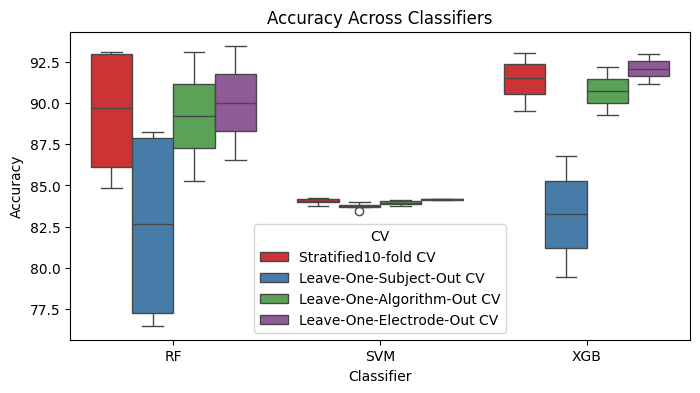

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_result, x='Classifier', y='Accuracy', hue= 'CV', palette='Set1')
plt.title('Accuracy Across Classifiers')
plt.show()

ValueError: Could not interpret value `Expert` for `hue`. An entry with this name does not appear in `data`.

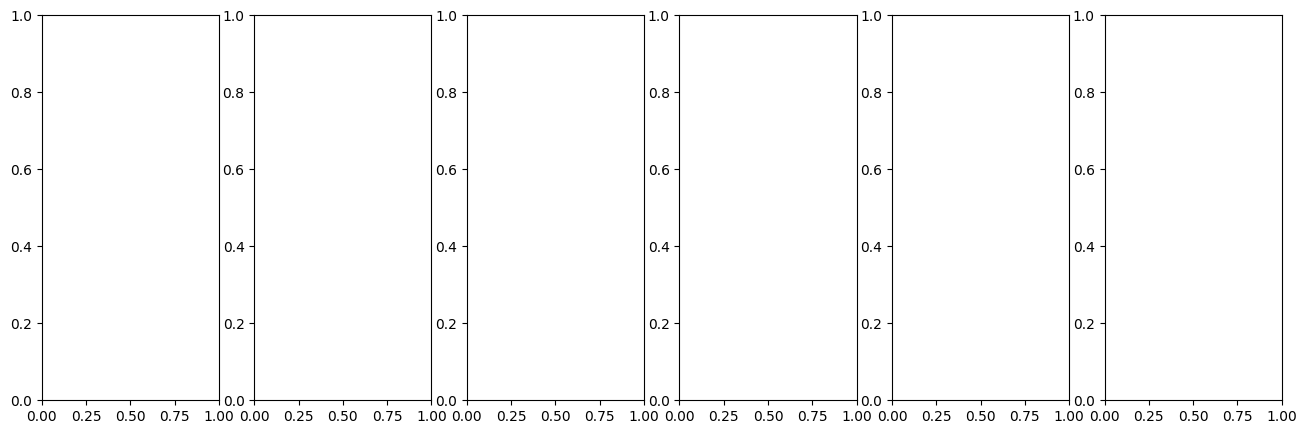

In [19]:
metric= ['Expert Precision','Expert Recall', 'Expert F1-Score',
    'Novice Precision','Novice Recall', 'Novice F1-Score']

# Create subplots
fig, axs = plt.subplots(1, len(metric), figsize=(16, 5))

# Iterate over each metric
for i, metric in enumerate(metric):
    class_name = metric.split()[0]
    sns.boxplot(data=df_result, x='Classifier', y=metric, hue= class_name, palette='Set1', ax=axs[i])
    axs[i].set_title(f'{metric} Across Classifiers' , fontsize=10)
    axs[i].legend(title=class_name)

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

In [22]:
df_result.head(0)

,Focus,Data,FrequencyBand,X_shape,y_shape,Classifier,CV,Accuracy,Expert Precision,Expert Recall,Expert F1-Score,Expert Support,Novice Precision,Novice Recall,Novice F1-Score,Novice Support,Best Group,Best Accuracy


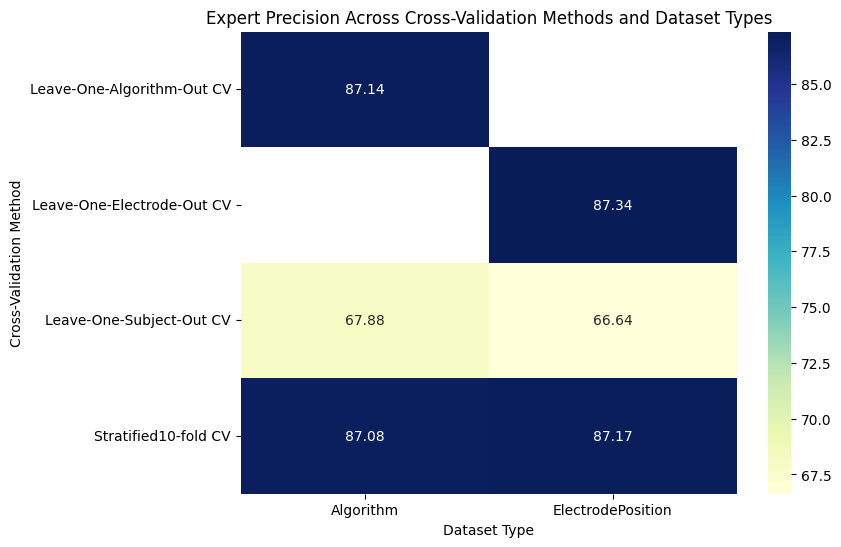

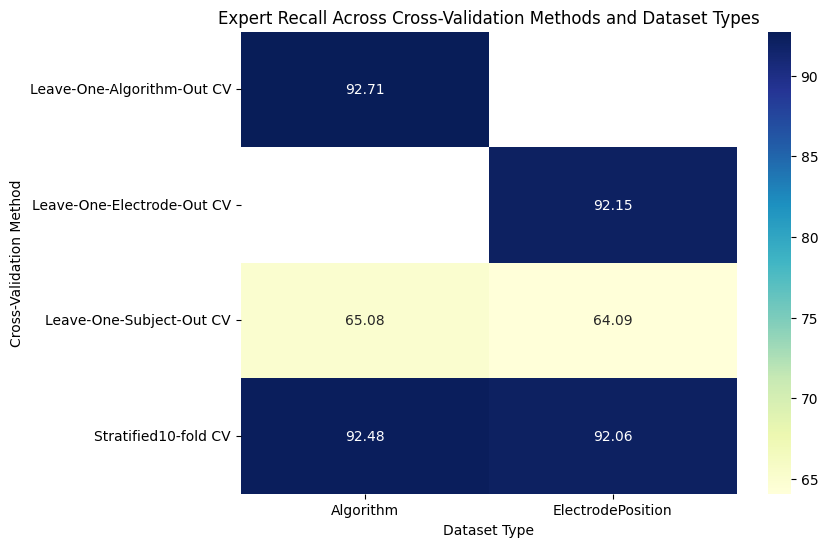

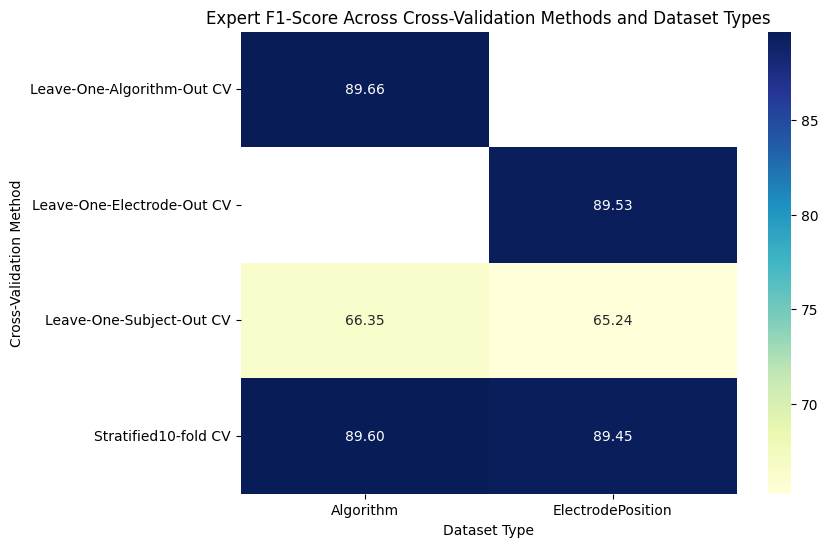

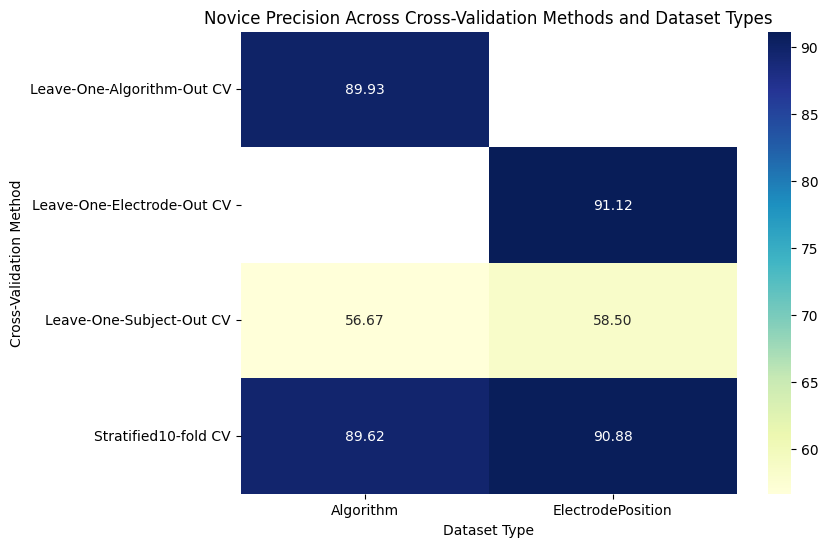

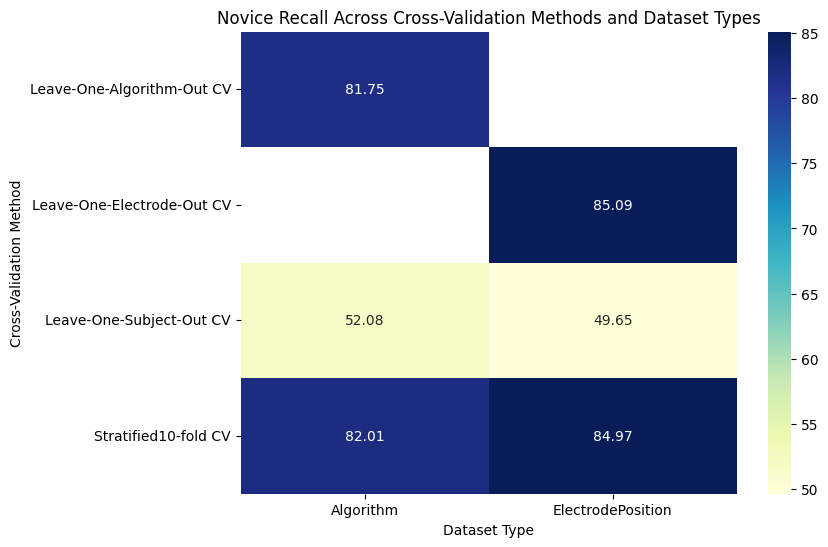

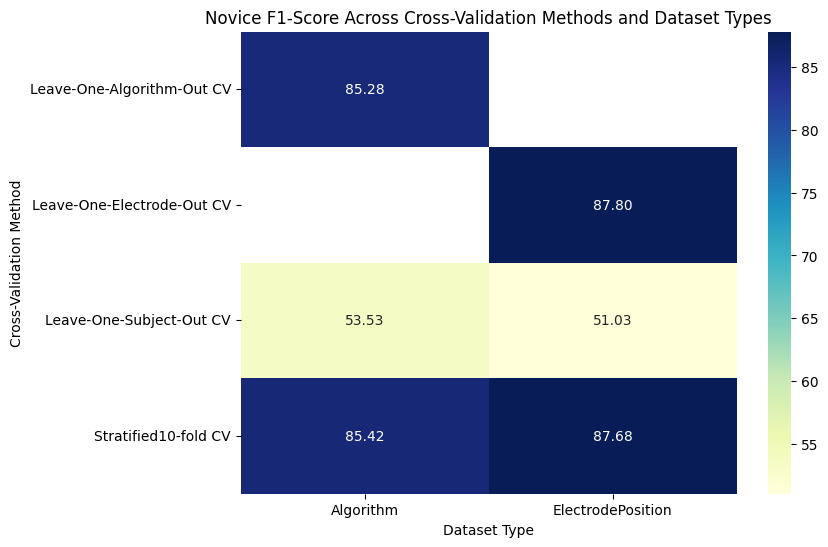

In [24]:
metrics= ['Expert Precision','Expert Recall', 'Expert F1-Score',
    'Novice Precision','Novice Recall', 'Novice F1-Score']
for metric in metrics:
    pivot_table = df_result.pivot_table(values=metric, index='CV', columns='Focus', aggfunc='mean')
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title(f'{metric} Across Cross-Validation Methods and Dataset Types')
    plt.xlabel('Dataset Type')
    plt.ylabel('Cross-Validation Method')
    plt.show()

C:\Users\Mahima Acharya\AppData\Local\Temp\ipykernel_25584\3857264821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_result, x='Classifier', y='Expert Recall', palette='Set2')


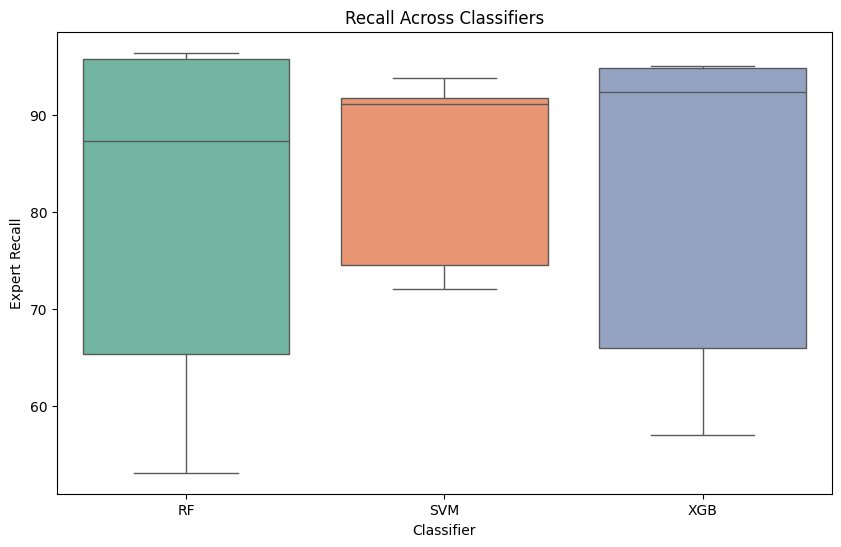

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_result, x='Classifier', y='Expert Recall', palette='Set2')
plt.title('Recall Across Classifiers')
plt.show()

In [29]:
df_test = df_result.loc[0]
df_test

Focus                                                    Algorithm
Data                                             CodeComprehension
FrequencyBand                                              4to50hz
X_shape                                                   (727, 1)
y_shape                                                     (727,)
Classifier                                                      RF
CV                                            Stratified10-fold CV
Accuracy                                                   84.8744
Expert Report    {'precision': 87.03, 'recall': 86.02, 'f1-scor...
Novice Report    {'precision': 82.55, 'recall': 83.37, 'f1-scor...
Best Group                                                     NaN
Best Accuracy                                                  NaN
Name: 0, dtype: object

In [31]:
pd.DataFrame.from_dict(df_test['Expert Report'], orient='tight')

TypeError: string indices must be integers

In [30]:


def listup(initlist):
    # Converting string to list 
    res = ini_list.strip('][').split(', ') 
    
    return res


report = df_test["Expert Report"].apply(ast.literal_eval).tolist()


AttributeError: 'str' object has no attribute 'apply'

In [23]:
df_check = df_test['Expert Report'].tolist()

TypeError: string indices must be integers

In [22]:
import ast


# Now, you can access 'value_a' from each row
df_check = df_test['Expert Report'].apply(lambda x: ast.literal_eval(x) )
df_check

TypeError: string indices must be integers

In [18]:
def extract_values(dictionary):
    precision = dictionary['precision']
    recall = dictionary['recall']
    f1score = dictionary['f1-score']
    support = dictionary['support']
    return precision, recall, f1score, support

df_test[['precision', 'recall', 'f1-score', 'support']] = df_test['Expert Report'].apply(lambda x: pd.Series(extract_values(x)))
print(df_test)

TypeError: string indices must be integers

In [ ]:

sns.set(style="whitegrid")
# Number of plots to create
"""num_plots = 8
rows_per_plot = 9
plots_per_row = 4"""

num_plots = 4
rows_per_plot = 9
plots_per_row = 2

cv_names = ['Stratified10-fold CV', 'Leave-One-Subject-Out CV', 'Leave-One-Algorithm-Out CV', 'Leave-One-Electrode-Out CV']
cv_colors = {cv_name: cm.inferno(i/(len(cv_names))) for i, cv_name in enumerate(cv_names)}



# Create a grid of subplots with two rows
fig, axes = plt.subplots(nrows=2, ncols=plots_per_row, figsize=(10,6 ))


# Loop through the plots
for i in range(num_plots):
    # Select 9 rows for the current plot
    start_idx = i * rows_per_plot
    end_idx = (i + 1) * rows_per_plot
    subset_df = df_result.iloc[start_idx:end_idx, :]
    focus = df_result.iloc[start_idx]['Focus']
    data = df_result.iloc[start_idx]['Data']
    freq_band = df_result.iloc[start_idx]['FrequencyBand']
    # Determine the subplot position
    row_idx = i // plots_per_row
    col_idx = i % plots_per_row

    # Create a bar plot for accuracy vs classifier
    ax = sns.barplot(x="Classifier", y="Accuracy", hue="CV", data=subset_df, ax=axes[row_idx, col_idx], 
                     ci=None,palette=cv_colors)

    focus_name = "Alg" if focus == "Algorithm" else "EP"
    
    # Customize plot aesthetics
    ax.set_title(f"{i + 1}: {focus_name}_{data}_{freq_band}")
    ax.set_xlabel("Classifier")
    ax.set_ylabel("Accuracy")
    ax.legend().set_visible(False)
    

    # Set y-axis ticks with a distance of 0.1
    ax.set_yticks([tick / 10 for tick in range(11)])

    # Show the legend only for plots 4 and 8
    ax.legend().set_visible(False)

   
# Create a custom legend based on the color palette
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in cv_colors.values()]
legend_names = list(cv_colors.keys())

"""#label bar for 8 plots
plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
           bbox_to_anchor=(-1.5, -0.1), loc='upper center', ncol=4).set_visible(True)"""
#label bar for 4 plots
plt.legend(legend_labels, legend_names, title="Cross Validation Method", 
           bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1).set_visible(True)

plt.suptitle('Binary Classification (Expert vs. Novice)',fontsize=16, fontweight='bold')
#plt.suptitle('Multiclass Classification (Expert vs. Intermediate vs. Novice)',fontsize=16, fontweight='bold')
# Adjust the layout to prevent clipping of titles
plt.subplots_adjust(top=0.9)

# Adjust layout and show the plots
plt.tight_layout(pad= 2)
plt.savefig(result_plot + '/bin_clf_result_accuracy.png')
#plt.savefig(result_plot + '/mcl_clf_result_accuracy.png')
plt.show()
